# 05a — Robustness Sweeps (Scenario A) — Greedy Baseline

This notebook runs a classical **greedy/additive** baseline for Scenario A by selecting the top-K trials under:

**score = benefit − λ_cost · cost − λ_safety · safety**

It then sweep-tests robustness across:
- `K` (portfolio size)
- `λ_cost`, `λ_safety` (trade-off weights)
- `noise_sigma` (optional multiplicative perturbation on benefit/cost/safety)
- `seed` (repeatability across perturbations)

Artifacts are written with a **greedy-specific prefix** to avoid collisions:
- `data/results/05a_greedy_robustness_sweep_summary.csv`
- `data/results/05a_greedy_top_configs_selected_trials.csv`
- `data/results/05a_greedy_top_config_table.csv`
- `outputs/figures/05a_greedy_objective_heatmap.png`
- `outputs/figures/05a_greedy_jaccard_vs_baseline.png`


In [13]:
# ============================================================
# Cell 1 — Setup: imports, paths, and output directories
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Project directories ---
DATA_DIR = Path("data")
RESULTS_DIR = DATA_DIR / "results"
SCENARIOS_DIR = DATA_DIR / "scenarios"
FIG_DIR = Path("outputs") / "figures"

# Create output directories if missing
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Input files (Scenario A) ---
# Prefer the Scenario A candidate file if present; otherwise fall back to the 03e artifact.
PATH_SCENARIO_A_TRIALS = SCENARIOS_DIR / "scenario_A_trials.csv"
PATH_QAOA_SELECTED     = RESULTS_DIR / "03e_scenario_A_selected_trials.csv"
PATH_QAOA_SUMMARY      = RESULTS_DIR / "03e_scenario_A_summary.csv"

# --- Outputs (greedy-specific prefix to avoid collisions) ---
OUT_PREFIX = "05a_greedy"
PATH_SWEEP_SUMMARY = RESULTS_DIR / f"{OUT_PREFIX}_robustness_sweep_summary.csv"
PATH_TOP_SELECTED  = RESULTS_DIR / f"{OUT_PREFIX}_top_configs_selected_trials.csv"
PATH_TOP_TABLE     = RESULTS_DIR / f"{OUT_PREFIX}_top_config_table.csv"
PATH_FIG_HEATMAP   = FIG_DIR     / f"{OUT_PREFIX}_objective_heatmap.png"
PATH_FIG_JACCARD   = FIG_DIR     / f"{OUT_PREFIX}_jaccard_vs_baseline.png"

# --- Quick existence checks (keeps notebook friendly) ---
if not PATH_SCENARIO_A_TRIALS.exists() and not PATH_QAOA_SELECTED.exists():
    raise FileNotFoundError(
        "Missing Scenario A candidates.\n"
        f"Expected one of:\n"
        f"  - {PATH_SCENARIO_A_TRIALS}\n"
        f"  - {PATH_QAOA_SELECTED}\n"
        "Fix: generate Scenario A candidates or update paths in Cell 1."
    )

# 03e summary is helpful but not strictly required for this notebook
if PATH_QAOA_SELECTED.exists() and not PATH_QAOA_SUMMARY.exists():
    print(f"Note: {PATH_QAOA_SUMMARY} not found (OK for greedy sweep).")

print("OK: Paths initialized.")
print("Results dir:", RESULTS_DIR.resolve())
print("Figures dir:", FIG_DIR.resolve())
print("Candidate source preference:", PATH_SCENARIO_A_TRIALS, "-> fallback:", PATH_QAOA_SELECTED)


OK: Paths initialized.
Results dir: /home/parallels/projects/quantum-clinical-trial-optimization/data/results
Figures dir: /home/parallels/projects/quantum-clinical-trial-optimization/outputs/figures
Candidate source preference: data/scenarios/scenario_A_trials.csv -> fallback: data/results/03e_scenario_A_selected_trials.csv


### What Cell 1 Just Did

- Imported core libraries and set a global random seed for repeatability.
- Defined input and output paths for Scenario A and created output directories.
- Ensured we have *at least one* valid Scenario A candidate source to load.
- Set greedy-specific output filenames (`05a_greedy_*`) so this notebook won’t overwrite other Phase 5 artifacts.


In [15]:
# ============================================================
# Cell 2 — Load Scenario A candidates and standardize columns
# ============================================================

# --- Load from preferred source ---
if PATH_SCENARIO_A_TRIALS.exists():
    candidates = pd.read_csv(PATH_SCENARIO_A_TRIALS)
    source_path = PATH_SCENARIO_A_TRIALS
else:
    candidates = pd.read_csv(PATH_QAOA_SELECTED)
    source_path = PATH_QAOA_SELECTED

print(f"Loaded candidates from: {source_path}")
print("Raw shape:", candidates.shape)

# --- Standardize trial identifier to `nct_id` ---
id_candidates = ["nct_id", "NCT_ID", "trial_id", "TrialID", "id"]
found_id = next((c for c in id_candidates if c in candidates.columns), None)
if found_id is None:
    raise ValueError(
        "No trial identifier column found.\n"
        f"Expected one of: {id_candidates}\n"
        f"Columns present: {list(candidates.columns)}"
    )
if found_id != "nct_id":
    candidates = candidates.rename(columns={found_id: "nct_id"})

# --- Standardize scoring components into raw columns ---
# We require three non-negative components:
#   _benefit_raw, _cost_raw, _safety_raw
#
# Your candidate file currently includes:
#   - benefit_score
#   - estimated_trial_cost
#   - enrollment_feasibility_score
#
# We'll map:
#   benefit  <- benefit_score (higher is better)
#   cost     <- estimated_trial_cost (higher is worse)
#   safety   <- feasibility_penalty derived from enrollment_feasibility_score (higher is worse)

benefit_candidates = ["_benefit_raw", "benefit_raw", "benefit", "Benefit", "utility", "objective_benefit", "benefit_score"]
cost_candidates    = ["_cost_raw", "cost_raw", "cost", "Cost", "objective_cost", "estimated_trial_cost"]
safety_candidates  = ["_safety_raw", "safety_raw", "safety", "Safety", "risk", "objective_safety", "safety_score"]

def first_present(cols):
    return next((c for c in cols if c in candidates.columns), None)

bcol = first_present(benefit_candidates)
ccol = first_present(cost_candidates)
scol = first_present(safety_candidates)

# Rename benefit/cost into standardized raw columns
rename_map = {}
if bcol is not None and bcol != "_benefit_raw":
    rename_map[bcol] = "_benefit_raw"
if ccol is not None and ccol != "_cost_raw":
    rename_map[ccol] = "_cost_raw"
candidates = candidates.rename(columns=rename_map)

# Ensure benefit/cost exist after mapping
if "_benefit_raw" not in candidates.columns or "_cost_raw" not in candidates.columns:
    raise ValueError(
        "Missing required benefit/cost columns even after mapping.\n"
        f"Found benefit col: {bcol}, cost col: {ccol}\n"
        f"Columns present: {list(candidates.columns)}"
    )

# If safety/risk column doesn't exist, derive a penalty from feasibility
if "_safety_raw" not in candidates.columns:
    if "enrollment_feasibility_score" not in candidates.columns:
        # last-resort: no safety signal available; set zero penalty
        candidates["_safety_raw"] = 0.0
        print("Warning: No safety/risk or feasibility column found. Setting _safety_raw = 0.0 for all rows.")
    else:
        feas = pd.to_numeric(candidates["enrollment_feasibility_score"], errors="coerce")
        if feas.isna().any():
            n_bad = int(feas.isna().sum())
            raise ValueError(f"enrollment_feasibility_score contains {n_bad} NaNs after numeric coercion. Fix upstream.")
        # Convert feasibility into a penalty: penalty = max(feas) - feas (then clamp >= 0)
        candidates["_safety_raw"] = (float(feas.max()) - feas).clip(lower=0.0)
        print("Derived _safety_raw from enrollment_feasibility_score as (max(feas) - feas).")
else:
    # If a safety column exists, ensure it ends up named _safety_raw
    if scol is not None and scol != "_safety_raw" and scol in candidates.columns:
        candidates = candidates.rename(columns={scol: "_safety_raw"})

# Coerce to numeric, forbid NaNs, and clamp to non-negative
for col in ["_benefit_raw", "_cost_raw", "_safety_raw"]:
    candidates[col] = pd.to_numeric(candidates[col], errors="coerce")
    if candidates[col].isna().any():
        n_bad = int(candidates[col].isna().sum())
        raise ValueError(f"{col} contains {n_bad} NaNs after numeric coercion. Fix upstream.")
    candidates[col] = candidates[col].clip(lower=0.0)

# Working copies (may be perturbed during sweeps)
candidates["_benefit"] = candidates["_benefit_raw"].astype(float)
candidates["_cost"]    = candidates["_cost_raw"].astype(float)
candidates["_safety"]  = candidates["_safety_raw"].astype(float)

# One row per trial; stable ordering for deterministic tie-breaks
candidates = (
    candidates.drop_duplicates(subset=["nct_id"])
              .sort_values("nct_id")
              .reset_index(drop=True)
)

print("Standardized preview:")
display(candidates[["nct_id", "_benefit_raw", "_cost_raw", "_safety_raw"]].head(10))
print("Final candidate shape:", candidates.shape)


Loaded candidates from: data/scenarios/scenario_A_trials.csv
Raw shape: (16672, 13)
Derived _safety_raw from enrollment_feasibility_score as (max(feas) - feas).
Standardized preview:


,nct_id,_benefit_raw,_cost_raw,_safety_raw
0,NCT00002462,0.8,4.0,0.0
1,NCT00003042,0.6,2.0,0.0
2,NCT00003641,0.8,4.0,0.0
3,NCT00005584,0.8,4.0,0.0
4,NCT00006721,0.8,4.0,0.0
5,NCT00007150,0.6,2.0,0.0
6,NCT00018057,0.6,2.0,0.0
7,NCT00026312,0.8,4.0,0.0
8,NCT00044304,0.6,2.0,0.0
9,NCT00070499,0.6,2.0,0.0


Final candidate shape: (16672, 17)


### What Cell 2 Just Did

- Loaded Scenario A candidate trials from `data/scenarios/scenario_A_trials.csv` (falling back to `data/results/03e_scenario_A_selected_trials.csv` if needed).
- Standardized the trial identifier to `nct_id`.
- Mapped your available scoring columns into an additive “benefit/cost/safety-penalty” contract:
  - `_benefit_raw` ← `benefit_score`
  - `_cost_raw` ← `estimated_trial_cost`
  - `_safety_raw` derived from `enrollment_feasibility_score` as `(max(feasibility) − feasibility)` so higher values represent a larger penalty.
- Enforced numeric types, disallowed NaNs in the scoring components, clamped to non-negative values, and created working copies (`_benefit`, `_cost`, `_safety`) for perturbation in later robustness sweeps.
- Deduplicated on `nct_id` and applied a stable sort for deterministic tie-breaking.


In [16]:
# ============================================================
# Cell 3 — Greedy selector, metrics, and stability utilities
# ============================================================

from dataclasses import dataclass

@dataclass(frozen=True)
class Config:
    K: int
    lambda_cost: float
    lambda_safety: float
    noise_sigma: float
    seed: int

def compute_trial_score(df: pd.DataFrame, lc: float, ls: float) -> pd.Series:
    # Additive score; higher is better
    return df["_benefit"] - (lc * df["_cost"]) - (ls * df["_safety"])

def select_greedy_additive(df: pd.DataFrame, K: int, lc: float, ls: float) -> pd.DataFrame:
    """
    Greedy baseline for additive objective:
      score_i = benefit_i - lc*cost_i - ls*safety_i
    Select top-K by score, with stable tie-break on nct_id.
    """
    if K <= 0:
        return df.iloc[0:0].copy()

    work = df.copy()
    work["_score"] = compute_trial_score(work, lc, ls)
    work = work.sort_values(["_score", "nct_id"], ascending=[False, True]).head(K).reset_index(drop=True)
    return work

def portfolio_metrics(selected: pd.DataFrame, lc: float, ls: float) -> dict:
    total_benefit = float(selected["_benefit"].sum()) if not selected.empty else 0.0
    total_cost    = float(selected["_cost"].sum())    if not selected.empty else 0.0
    total_safety  = float(selected["_safety"].sum())  if not selected.empty else 0.0
    objective = total_benefit - (lc * total_cost) - (ls * total_safety)

    return {
        "selected_n": int(len(selected)),
        "total_benefit": total_benefit,
        "total_cost": total_cost,
        "total_safety": total_safety,
        "objective": float(objective),
    }

def jaccard(a_ids, b_ids) -> float:
    a = set(a_ids)
    b = set(b_ids)
    if not a and not b:
        return 1.0
    if not a or not b:
        return 0.0
    return len(a & b) / len(a | b)

def config_id(cfg: Config) -> str:
    # Compact, filesystem-safe identifier
    return f"K{cfg.K}_lc{cfg.lambda_cost:.4g}_ls{cfg.lambda_safety:.4g}_sig{cfg.noise_sigma:.3g}_seed{cfg.seed}"

print("OK: Greedy + metrics utilities defined.")


OK: Greedy + metrics utilities defined.


### What Cell 3 Just Did

- Defined a `Config` object that uniquely identifies a sweep run (K, λ weights, noise strength, seed).
- Implemented the greedy additive selector used as the baseline in Scenario A.
- Implemented consistent portfolio metrics and a Jaccard similarity helper to quantify selection stability.
- Added a compact `config_id` string used in output tables and artifact naming.


In [17]:
# ============================================================
# Cell 4 — Robustness sweep: grid + perturbations + artifacts
# ============================================================

# --- Sweep grid (edit these as needed) ---
K_values = [25, 50, 75]
lambda_cost_values = [0.5, 1.0, 2.0]
lambda_safety_values = [0.5, 1.0, 2.0]

# Robustness: multiplicative lognormal noise on raw components
noise_sigmas = [0.0, 0.05, 0.10]
seeds = [0, 1, 2, 3, 4]

# Baseline config used for stability comparisons (must be within grid)
BASELINE = Config(K=50, lambda_cost=1.0, lambda_safety=1.0, noise_sigma=0.0, seed=0)

def perturb_components(df: pd.DataFrame, noise_sigma: float, seed: int) -> pd.DataFrame:
    """
    Apply multiplicative lognormal noise to _benefit_raw/_cost_raw/_safety_raw
    and write into working columns _benefit/_cost/_safety (non-negative).
    """
    out = df.copy()
    if noise_sigma <= 0.0:
        out["_benefit"] = out["_benefit_raw"].astype(float)
        out["_cost"]    = out["_cost_raw"].astype(float)
        out["_safety"]  = out["_safety_raw"].astype(float)
        return out

    rng = np.random.default_rng(seed)
    f_b = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))
    f_c = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))
    f_s = rng.lognormal(mean=0.0, sigma=noise_sigma, size=len(out))

    out["_benefit"] = np.clip(out["_benefit_raw"].to_numpy(float) * f_b, 0.0, None)
    out["_cost"]    = np.clip(out["_cost_raw"].to_numpy(float)    * f_c, 0.0, None)
    out["_safety"]  = np.clip(out["_safety_raw"].to_numpy(float)  * f_s, 0.0, None)
    return out

# --- Establish baseline selection set ---
baseline_df = perturb_components(candidates, BASELINE.noise_sigma, BASELINE.seed)
baseline_sel = select_greedy_additive(baseline_df, BASELINE.K, BASELINE.lambda_cost, BASELINE.lambda_safety)
baseline_set = set(baseline_sel["nct_id"].tolist())

print("Baseline config:", BASELINE)
print("Baseline selected_n:", len(baseline_set))

# --- Run sweep ---
rows = []

for K in K_values:
    for lc in lambda_cost_values:
        for ls in lambda_safety_values:
            for sig in noise_sigmas:
                for seed in seeds:
                    cfg = Config(K=K, lambda_cost=lc, lambda_safety=ls, noise_sigma=sig, seed=seed)

                    work_df = perturb_components(candidates, sig, seed)
                    sel = select_greedy_additive(work_df, K, lc, ls)

                    mets = portfolio_metrics(sel, lc, ls)
                    jac = jaccard(sel["nct_id"].tolist(), baseline_set)

                    rows.append({
                        "config_id": config_id(cfg),
                        "K": cfg.K,
                        "lambda_cost": cfg.lambda_cost,
                        "lambda_safety": cfg.lambda_safety,
                        "noise_sigma": cfg.noise_sigma,
                        "seed": cfg.seed,
                        "jaccard_vs_baseline": float(jac),
                        **mets,
                    })

summary_df = pd.DataFrame(rows)

# --- Normalize objective across the sweep for comparability ---
obj_min = float(summary_df["objective"].min())
obj_max = float(summary_df["objective"].max())
den = (obj_max - obj_min) if (obj_max > obj_min) else 1.0
summary_df["objective_norm"] = (summary_df["objective"] - obj_min) / den

# --- Save sweep summary ---
summary_df.to_csv(PATH_SWEEP_SUMMARY, index=False)
print("Wrote:", PATH_SWEEP_SUMMARY)

# --- Aggregate per configuration (mean/std across seeds) ---
group_cols = ["K", "lambda_cost", "lambda_safety", "noise_sigma"]
agg = (
    summary_df.groupby(group_cols, as_index=False)
    .agg(
        objective_mean=("objective", "mean"),
        objective_std=("objective", "std"),
        objective_norm_mean=("objective_norm", "mean"),
        jaccard_mean=("jaccard_vs_baseline", "mean"),
        jaccard_std=("jaccard_vs_baseline", "std"),
        n_runs=("objective", "size"),
    )
)

# --- Choose top configs by objective_norm_mean, break ties by stability ---
TOP_N = 10
top_configs = (
    agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False])
       .head(TOP_N)
       .reset_index(drop=True)
)

top_configs.to_csv(PATH_TOP_TABLE, index=False)
print("Wrote:", PATH_TOP_TABLE)

# --- Materialize selected trials for each top config (seed=0 for reproducibility) ---
selected_trials_blocks = []
for _, r in top_configs.iterrows():
    cfg0 = Config(
        K=int(r["K"]),
        lambda_cost=float(r["lambda_cost"]),
        lambda_safety=float(r["lambda_safety"]),
        noise_sigma=float(r["noise_sigma"]),
        seed=0,
    )
    work_df0 = perturb_components(candidates, cfg0.noise_sigma, cfg0.seed)
    sel0 = select_greedy_additive(work_df0, cfg0.K, cfg0.lambda_cost, cfg0.lambda_safety).copy()

    sel0["config_id"] = config_id(cfg0)
    sel0["K"] = cfg0.K
    sel0["lambda_cost"] = cfg0.lambda_cost
    sel0["lambda_safety"] = cfg0.lambda_safety
    sel0["noise_sigma"] = cfg0.noise_sigma
    sel0["seed"] = cfg0.seed

    selected_trials_blocks.append(sel0)

top_selected_trials_df = pd.concat(selected_trials_blocks, ignore_index=True) if selected_trials_blocks else pd.DataFrame()
top_selected_trials_df.to_csv(PATH_TOP_SELECTED, index=False)
print("Wrote:", PATH_TOP_SELECTED)

display(top_configs)


Baseline config: Config(K=50, lambda_cost=1.0, lambda_safety=1.0, noise_sigma=0.0, seed=0)
Baseline selected_n: 50
Wrote: data/results/05a_greedy_robustness_sweep_summary.csv
Wrote: data/results/05a_greedy_top_config_table.csv
Wrote: data/results/05a_greedy_top_configs_selected_trials.csv


,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
0,25,0.5,0.5,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
1,25,0.5,1.0,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
2,25,0.5,2.0,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
3,50,0.5,0.5,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
4,50,0.5,1.0,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
5,50,0.5,2.0,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
6,25,0.5,0.5,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
7,25,0.5,1.0,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
8,25,0.5,2.0,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
9,75,0.5,0.5,0.10,-7.069097,0.310146,0.977276,0.003226,0.004417,5


### What Cell 4 Just Did

- Defined the sweep grid over K, λ_cost, λ_safety, noise_sigma, and seed.
- Implemented a perturbation model (multiplicative lognormal noise) to test robustness under uncertainty.
- Computed a fixed baseline selection and measured stability of every run using Jaccard similarity.
- Wrote a sweep summary CSV, then aggregated results across seeds.
- Exported a “top configs” table and the selected trials for those top configs (seed=0) for reproducible inspection.


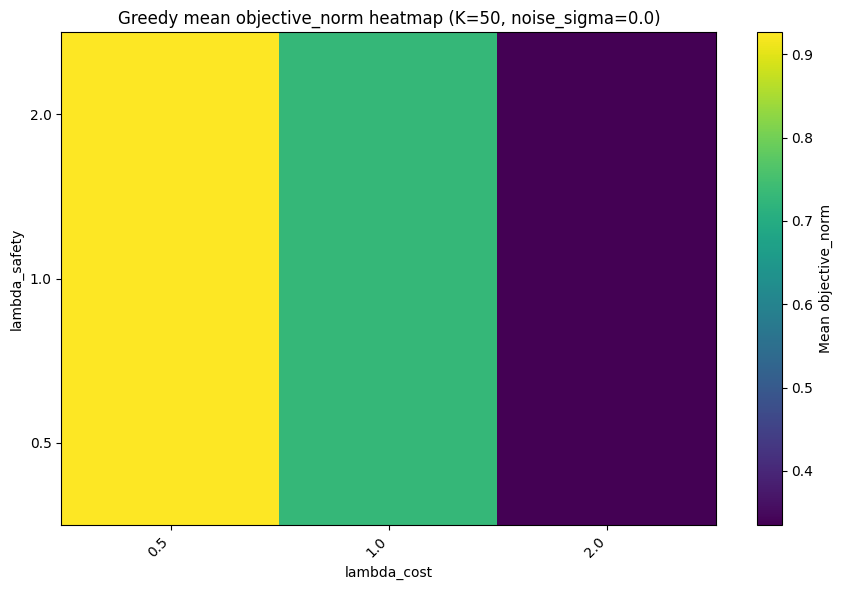

Saved: outputs/figures/05a_greedy_objective_heatmap.png


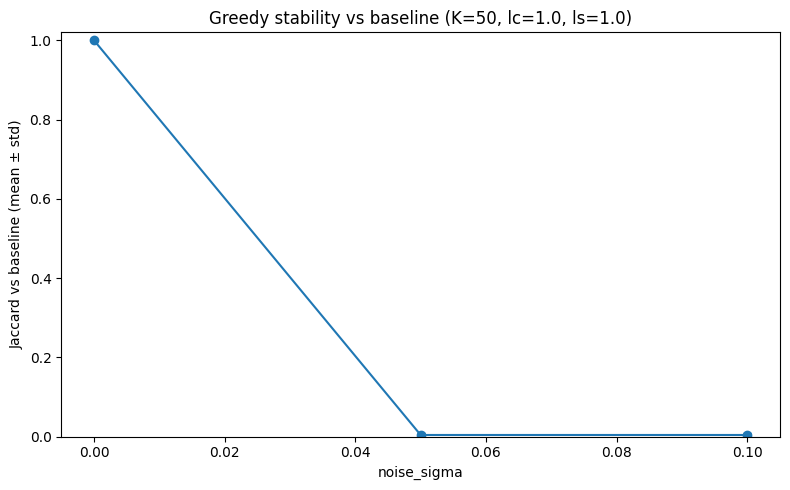

Saved: outputs/figures/05a_greedy_jaccard_vs_baseline.png


In [19]:
# ============================================================
# Cell 5 — Visuals: objective heatmap + Jaccard stability plot
# ============================================================

# --- Heatmap slice (edit for readability) ---
K_HEAT = 50
SIG_HEAT = 0.0

heat_slice = agg[(agg["K"] == K_HEAT) & (agg["noise_sigma"] == SIG_HEAT)].copy()
if heat_slice.empty:
    raise ValueError(f"No data for heatmap slice K={K_HEAT}, noise_sigma={SIG_HEAT}. Adjust K_HEAT/SIG_HEAT.")

pivot = (
    heat_slice.pivot(index="lambda_safety", columns="lambda_cost", values="objective_norm_mean")
              .sort_index(axis=0)
              .sort_index(axis=1)
)

plt.figure(figsize=(9, 6))
img = plt.imshow(pivot.values, aspect="auto", origin="lower")
plt.colorbar(img, label="Mean objective_norm")
plt.xticks(range(len(pivot.columns)), [str(x) for x in pivot.columns], rotation=45, ha="right")
plt.yticks(range(len(pivot.index)), [str(x) for x in pivot.index])
plt.xlabel("lambda_cost")
plt.ylabel("lambda_safety")
plt.title(f"Greedy mean objective_norm heatmap (K={K_HEAT}, noise_sigma={SIG_HEAT})")
plt.tight_layout()
plt.savefig(PATH_FIG_HEATMAP, dpi=160)
plt.show()

print("Saved:", PATH_FIG_HEATMAP)

# --- Jaccard vs noise plot for a single (K, lc, ls) slice ---
K_LINE = 50
LC_LINE = 1.0
LS_LINE = 1.0

line_slice = summary_df[
    (summary_df["K"] == K_LINE) &
    (summary_df["lambda_cost"] == LC_LINE) &
    (summary_df["lambda_safety"] == LS_LINE)
].copy()

if line_slice.empty:
    raise ValueError("No data for Jaccard line plot slice; adjust K_LINE/LC_LINE/LS_LINE.")

line_agg = (
    line_slice.groupby("noise_sigma", as_index=False)
              .agg(jaccard_mean=("jaccard_vs_baseline", "mean"),
                   jaccard_std=("jaccard_vs_baseline", "std"))
              .sort_values("noise_sigma")
)

plt.figure(figsize=(8, 5))
plt.errorbar(
    line_agg["noise_sigma"],
    line_agg["jaccard_mean"],
    yerr=line_agg["jaccard_std"],
    fmt="-o",
    capsize=3
)
plt.ylim(0, 1.02)
plt.xlabel("noise_sigma")
plt.ylabel("Jaccard vs baseline (mean ± std)")
plt.title(f"Greedy stability vs baseline (K={K_LINE}, lc={LC_LINE}, ls={LS_LINE})")
plt.tight_layout()
plt.savefig(PATH_FIG_JACCARD, dpi=160)
plt.show()

print("Saved:", PATH_FIG_JACCARD)


### What Cell 5 Just Did

- Created and saved an objective heatmap (mean normalized objective across λ_cost × λ_safety) for a chosen K/noise slice.
- Created and saved a stability plot showing how Jaccard similarity to the baseline changes as perturbation strength increases.
- These figures are designed to drop directly into slides and to support later comparisons with QAOA robustness results.


In [20]:
# ============================================================
# Cell 6 — Wrap-up: previews, artifact list, and sanity checks
# ============================================================

print("Sweep summary preview:")
display(summary_df.head(10))

print("\nAggregated config preview (top by objective_norm_mean):")
display(agg.sort_values(["objective_norm_mean", "jaccard_mean"], ascending=[False, False]).head(10))

print("\nArtifacts written:")
print("  -", PATH_SWEEP_SUMMARY)
print("  -", PATH_TOP_TABLE)
print("  -", PATH_TOP_SELECTED)
print("  -", PATH_FIG_HEATMAP)
print("  -", PATH_FIG_JACCARD)

# --- Sanity checks ---
assert summary_df["selected_n"].min() >= 0
assert summary_df["selected_n"].max() <= max(K_values)
assert summary_df["objective_norm"].between(0, 1).all()

print("\nSanity checks passed.")


Sweep summary preview:


,config_id,K,lambda_cost,lambda_safety,noise_sigma,seed,jaccard_vs_baseline,selected_n,total_benefit,total_cost,total_safety,objective,objective_norm
0,K25_lc0.5_ls0.5_sig0_seed0,25,0.5,0.5,0.00,0,0.500000,25,15.000000,50.000000,0.0,-10.000000,0.965723
1,K25_lc0.5_ls0.5_sig0_seed1,25,0.5,0.5,0.00,1,0.500000,25,15.000000,50.000000,0.0,-10.000000,0.965723
2,K25_lc0.5_ls0.5_sig0_seed2,25,0.5,0.5,0.00,2,0.500000,25,15.000000,50.000000,0.0,-10.000000,0.965723
3,K25_lc0.5_ls0.5_sig0_seed3,25,0.5,0.5,0.00,3,0.500000,25,15.000000,50.000000,0.0,-10.000000,0.965723
4,K25_lc0.5_ls0.5_sig0_seed4,25,0.5,0.5,0.00,4,0.500000,25,15.000000,50.000000,0.0,-10.000000,0.965723
5,K25_lc0.5_ls0.5_sig0.05_seed0,25,0.5,0.5,0.05,0,0.000000,25,16.492531,44.415382,0.0,-5.715160,0.982612
6,K25_lc0.5_ls0.5_sig0.05_seed1,25,0.5,0.5,0.05,1,0.000000,25,16.297627,43.741483,0.0,-5.573115,0.983172
7,K25_lc0.5_ls0.5_sig0.05_seed2,25,0.5,0.5,0.05,2,0.000000,25,16.561152,44.421391,0.0,-5.649543,0.982871
8,K25_lc0.5_ls0.5_sig0.05_seed3,25,0.5,0.5,0.05,3,0.000000,25,16.350554,44.115236,0.0,-5.707064,0.982644
9,K25_lc0.5_ls0.5_sig0.05_seed4,25,0.5,0.5,0.05,4,0.013514,25,16.646904,44.524591,0.0,-5.615391,0.983006



Aggregated config preview (top by objective_norm_mean):


,K,lambda_cost,lambda_safety,noise_sigma,objective_mean,objective_std,objective_norm_mean,jaccard_mean,jaccard_std,n_runs
2,25,0.5,0.5,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
5,25,0.5,1.0,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
8,25,0.5,2.0,0.10,-1.441677,0.118359,0.999457,0.002703,0.006043,5
29,50,0.5,0.5,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
32,50,0.5,1.0,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
35,50,0.5,2.0,0.10,-4.018448,0.166197,0.989300,0.002020,0.004517,5
1,25,0.5,0.5,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
4,25,0.5,1.0,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
7,25,0.5,2.0,0.05,-5.652055,0.060395,0.982861,0.002703,0.006043,5
56,75,0.5,0.5,0.10,-7.069097,0.310146,0.977276,0.003226,0.004417,5



Artifacts written:
  - data/results/05a_greedy_robustness_sweep_summary.csv
  - data/results/05a_greedy_top_config_table.csv
  - data/results/05a_greedy_top_configs_selected_trials.csv
  - outputs/figures/05a_greedy_objective_heatmap.png
  - outputs/figures/05a_greedy_jaccard_vs_baseline.png

Sanity checks passed.


### What Cell 6 Just Did

- Displayed quick previews of the raw sweep results and the aggregated configuration table.
- Printed the exact output artifact paths created by the notebook.
- Ran basic sanity checks to confirm selection sizes and objective normalization behave as expected.


## Summary

This notebook produces a reproducible **greedy baseline** robustness sweep for Scenario A that:
- uses an additive scoring contract adapted to your current candidate columns,
- tests stability under perturbations (`noise_sigma`, `seed`) and trade-off weights (λ),
- exports a sweep summary plus “top configs” selections,
- generates two presentation-ready figures (objective heatmap + stability plot),
- writes outputs under the `05a_greedy_*` prefix to avoid collisions with other Phase 5 artifacts.
